# DCIT407 LAB ASSIGNMENT 1

**Student ID:** 11126586  
**Course:** DCIT407

## Objectives
1. Load an image and apply Sobel X, Sobel Y, and a combined Sobel result.
2. Visualize gradient magnitude using `cv2.magnitude()`.
3. Create a binary edge map by thresholding gradient magnitude.
4. Use `cv2.phase()` to compute edge direction and visualize it in color.

## Methodology (Simple Steps I Followed)

1. I loaded one image from the `images` folder and converted it to grayscale.
2. I applied Sobel in the x-direction and y-direction to detect edges.
3. I combined Sobel X and Sobel Y to get a single edge response.
4. I computed gradient magnitude with `cv2.magnitude()`.
5. I converted the magnitude image to a binary edge map using thresholding.
6. I used `cv2.phase()` to calculate edge direction and displayed it in color.

This step-by-step process helped me see both edge strength and edge direction clearly.

In [20]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Display plots in a clean, consistent style
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["image.cmap"] = "gray"

## Step 1: Load an Input Image

This cell automatically searches common filenames in the `images` folder and loads the first match.

Loaded image: images\image2.jpg
Image shape (H, W, C): (416, 416, 3)


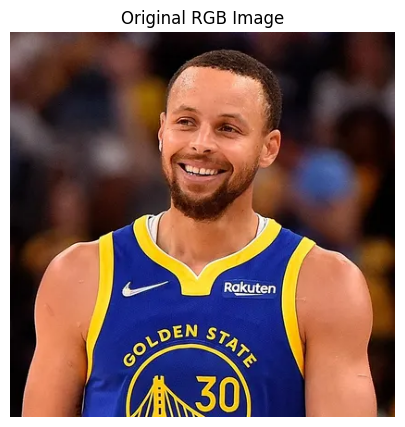

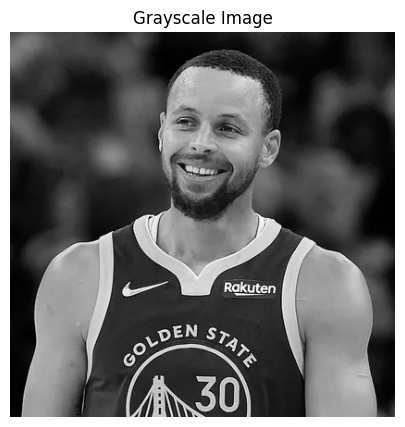

In [21]:
images_dir = "images"
candidates = [
    "image2.jpg",
    "image.jpg",
    "dog.png",
    "composite_result.jpg",
]

selected_path = None
for name in candidates:
    path = os.path.join(images_dir, name)
    if os.path.exists(path):
        selected_path = path
        break

if selected_path is None:
    raise FileNotFoundError("No valid image found in the images directory.")

img_bgr = cv2.imread(selected_path)
if img_bgr is None:
    raise ValueError(f"Failed to load image: {selected_path}")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

print(f"Loaded image: {selected_path}")
print(f"Image shape (H, W, C): {img_rgb.shape}")

plt.figure(figsize=(8, 5))
plt.imshow(img_rgb)
plt.title("Original RGB Image")
plt.axis("off")
plt.show()

plt.figure(figsize=(8, 5))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

## Step 2: Apply Sobel X, Sobel Y, and Combined Sobel

Compute horizontal and vertical gradients with Sobel filters, then combine them into a single edge response.

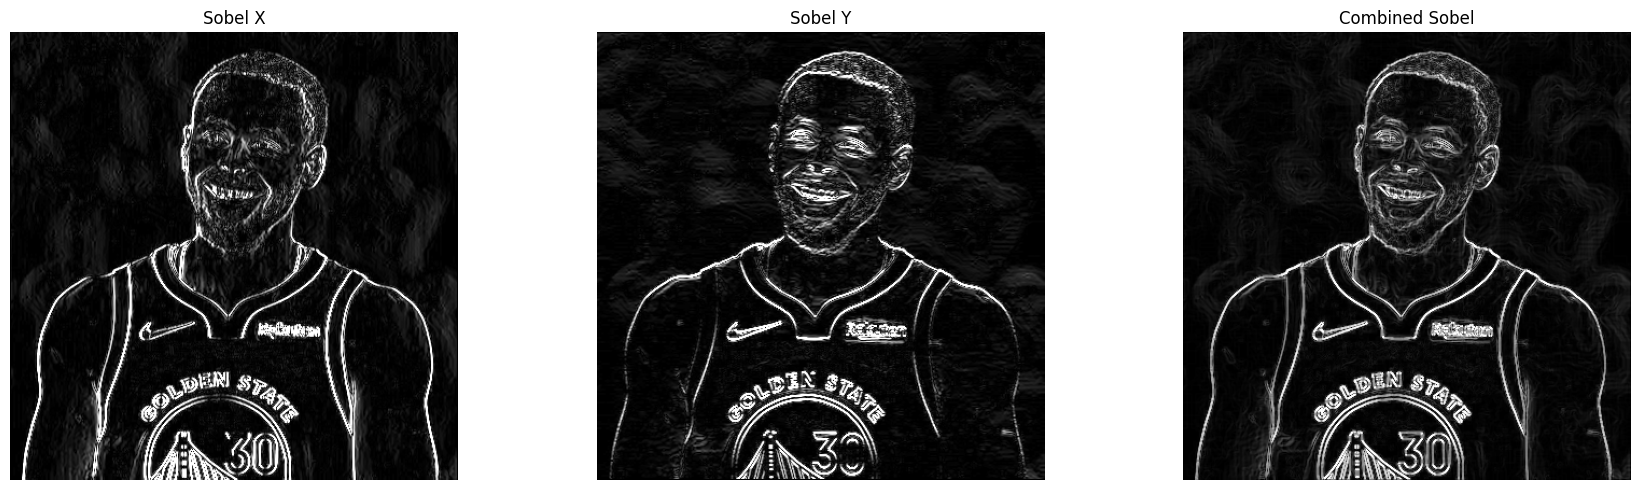

In [22]:
# Use float64 for accurate gradient computation
sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

# Combined Sobel via weighted sum of absolute responses
sobel_x_abs = cv2.convertScaleAbs(sobel_x)
sobel_y_abs = cv2.convertScaleAbs(sobel_y)
sobel_combined = cv2.addWeighted(sobel_x_abs, 0.5, sobel_y_abs, 0.5, 0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(sobel_x_abs, cmap="gray")
axes[0].set_title("Sobel X")
axes[0].axis("off")

axes[1].imshow(sobel_y_abs, cmap="gray")
axes[1].set_title("Sobel Y")
axes[1].axis("off")

axes[2].imshow(sobel_combined, cmap="gray")
axes[2].set_title("Combined Sobel")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## Step 3: Gradient Magnitude with `cv2.magnitude()`

Compute gradient magnitude from Sobel X and Sobel Y and visualize it.

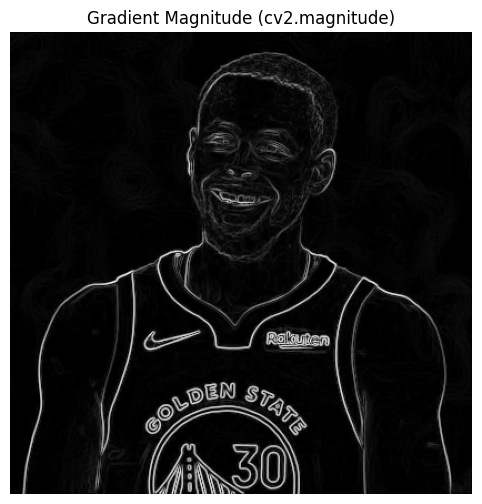

In [23]:
magnitude = cv2.magnitude(sobel_x.astype(np.float32), sobel_y.astype(np.float32))

# Normalize for visualization to [0, 255]
magnitude_norm = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX)
magnitude_uint8 = magnitude_norm.astype(np.uint8)

plt.figure(figsize=(10, 6))
plt.imshow(magnitude_uint8, cmap="gray")
plt.title("Gradient Magnitude (cv2.magnitude)")
plt.axis("off")
plt.show()

## Step 4: Binary Edge Map by Thresholding

Threshold the gradient magnitude to obtain a binary edge image.

Threshold used: 100


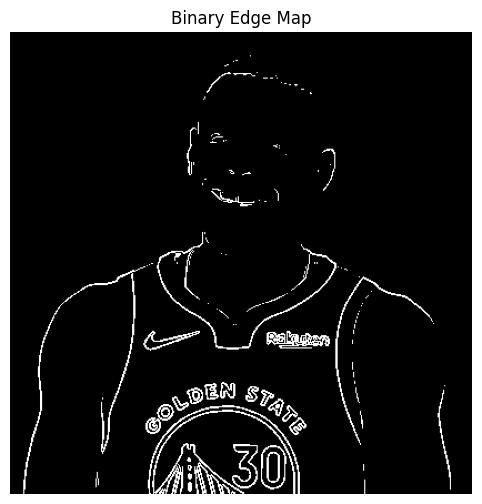

In [24]:
# You can tune this value depending on image content
threshold_value = 100
_, edge_binary = cv2.threshold(magnitude_uint8, threshold_value, 255, cv2.THRESH_BINARY)

print(f"Threshold used: {threshold_value}")

plt.figure(figsize=(10, 6))
plt.imshow(edge_binary, cmap="gray")
plt.title("Binary Edge Map")
plt.axis("off")
plt.show()

## Step 4b: Threshold Sensitivity Check

To justify the chosen threshold, we compare multiple threshold values and report the percentage of edge pixels produced by each one.

A very low threshold keeps noise, while a very high threshold removes useful edges.

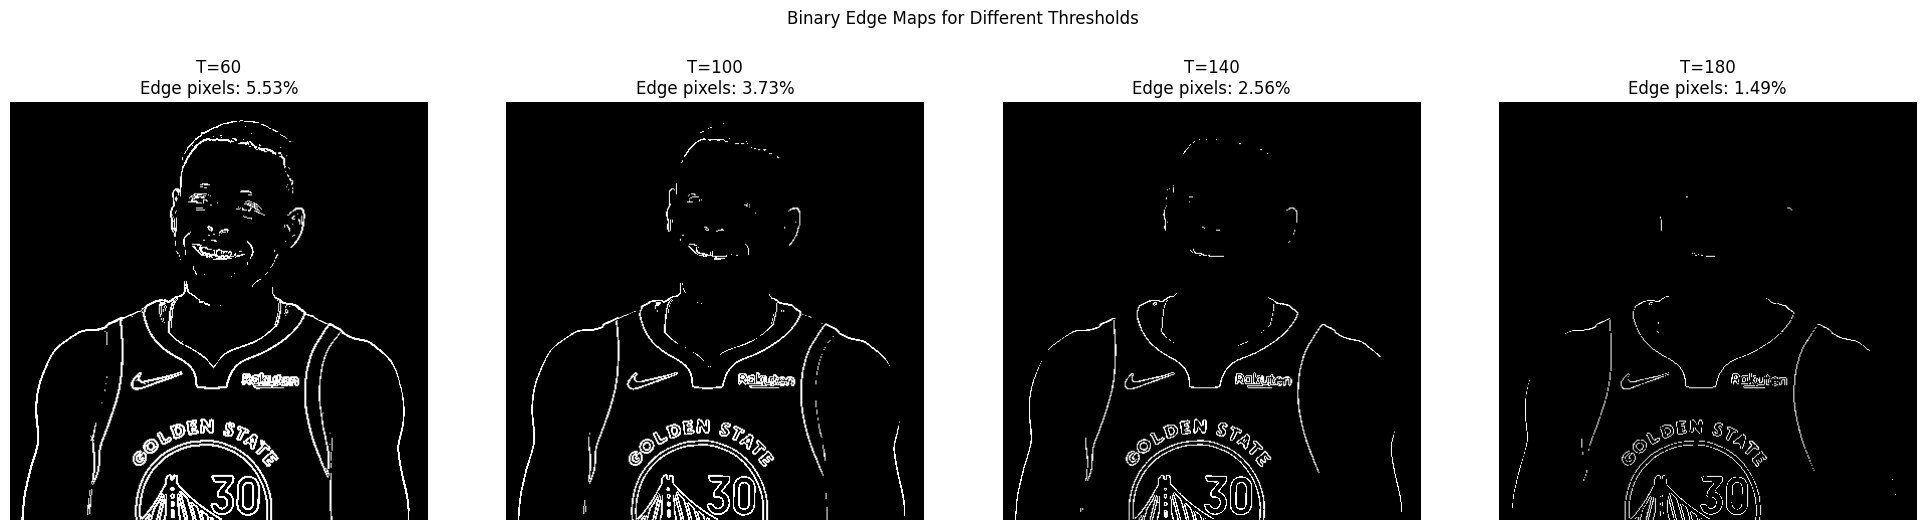

Threshold sensitivity summary:
  Threshold  60: 5.53% edge pixels
  Threshold 100: 3.73% edge pixels
  Threshold 140: 2.56% edge pixels
  Threshold 180: 1.49% edge pixels


In [25]:
test_thresholds = [60, 100, 140, 180]
edge_stats = []

fig, axes = plt.subplots(1, len(test_thresholds), figsize=(20, 5))
for i, t in enumerate(test_thresholds):
    _, edge_t = cv2.threshold(magnitude_uint8, t, 255, cv2.THRESH_BINARY)
    edge_ratio = (np.count_nonzero(edge_t) / edge_t.size) * 100
    edge_stats.append((t, edge_ratio))

    axes[i].imshow(edge_t, cmap="gray")
    axes[i].set_title(f"T={t}\nEdge pixels: {edge_ratio:.2f}%")
    axes[i].axis("off")

plt.suptitle("Binary Edge Maps for Different Thresholds", y=1.05)
plt.tight_layout()
plt.show()

print("Threshold sensitivity summary:")
for t, ratio in edge_stats:
    print(f"  Threshold {t:>3}: {ratio:.2f}% edge pixels")

## Step 5: Edge Direction with `cv2.phase()` and Color Visualization

Use phase (angle) as hue and gradient magnitude as brightness to build a directional edge map in color.

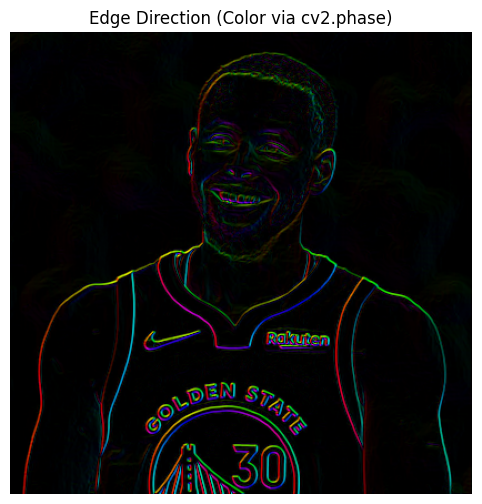

In [26]:
# Direction in radians [0, 2pi)
phase = cv2.phase(
    sobel_x.astype(np.float32),
    sobel_y.astype(np.float32),
    angleInDegrees=False,
)

# Build HSV image:
# H (0-179 in OpenCV) encodes angle, S is full, V encodes normalized magnitude
hue = (phase * 180 / np.pi / 2).astype(np.uint8)
value = magnitude_uint8
saturation = np.full_like(hue, 255, dtype=np.uint8)

hsv = cv2.merge([hue, saturation, value])
direction_bgr = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
direction_rgb = cv2.cvtColor(direction_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(direction_rgb)
plt.title("Edge Direction (Color via cv2.phase)")
plt.axis("off")
plt.show()

## Results and Discussion

- Sobel X highlighted mostly vertical edges, while Sobel Y highlighted mostly horizontal edges.
- The gradient magnitude image gave a cleaner overall view of strong edges.
- In my threshold test, lower thresholds kept more small details/noise, while higher thresholds removed many weak edges.
- I selected **threshold = 100** because it gave a good balance: key boundaries stayed visible and noise was reduced.
- The phase color map was useful because different colors showed different edge directions.

Overall, the experiment helped me understand that magnitude shows edge strength and phase shows edge orientation.

## Conclusion

All required tasks were completed successfully:
- Sobel X, Sobel Y, and combined Sobel were computed and visualized.
- Gradient magnitude was computed using `cv2.magnitude()`.
- A binary edge map was created by thresholding gradient magnitude.
- Edge direction was computed with `cv2.phase()` and visualized in color.

Based on the threshold comparison, `T = 100` was the best choice for this image because it preserved important edges while reducing background noise.